* EX2.9 (3 points): Expand the code from the second Quick Test in Section 2.2.1 in Lecture L06 to analyze simulation outputs stored in subfolders inside `simulation_data_files` folder in lecture L06.

  - For each subfolder:
    - Read the `.csv` file (`filename = subfolder_name + "_obs.csv"`)
    - Store it in a pandas DataFrame
    - Compute the mean of each observable:
      - HINT: `df.astype(float).mean()`

  - Build a bookkeeping DataFrame that contains:
    - The mean observables
    - The simulation parameters extracted from the folder name
    - HINT: store both in the same dictionary before adding to the DataFrame

  - Plot `surf_ch_dens` vs `pH` for:
    1) `sgD = 2.0`, `Rnp = 7.2`  
    2) `sgD = 1.0`, `Rnp = 10.1`
    - HINT: filter the DataFrame and sort by `pH
    - Note that the solutions showcased here include our python pet snake.
    - Your graphics must be free of snakes (i.e. please do not send us the figures included in this lecture!).


  - Save the final DataFrame to a Markdown file `simulation_data.md` inside a folder `simulation_data_for_publication`
    - HINT: you may need to install `tabulate` (`conda install tabulate`)

Solution:

<img src="figs/EX_6.3.png" alt="image" width="400" height="auto">

|   sgD |   Rnp |   pH |   number_A |   number_HA |       alpha |   surf_ch_dens |
|------:|------:|-----:|-----------:|------------:|------------:|---------------:|
|     2 |   7.2 |  4.5 |   0.20375  |    161.796  | 0.00125772  |     -0.403017  |
|     1 |  10.1 |  7.5 |  23.8513   |    138.149  | 0.14723     |    -23.5888    |
|     2 |   7.2 |  8   |  23.4542   |    138.546  | 0.144779    |    -46.3922    |
|     1 |  10.1 |  5.5 |   1.4975   |    160.502  | 0.00924383  |     -1.48102   |
|     1 |  10.1 |  7   |  14.9683   |    147.032  | 0.0923971   |    -14.8037    |
|     1 |  10.1 |  6.5 |   8.2075   |    153.792  | 0.0506636   |     -8.1172    |
|     1 |  10.1 |  9   |  65.3708   |     96.6292 | 0.403524    |    -64.6516    |
|     1 |  10.1 |  4.5 |   0.187083 |    161.813  | 0.00115484  |     -0.185025  |
|     2 |   7.2 |  7.5 |  16.9929   |    145.007  | 0.104895    |    -33.6119    |
|     1 |  10.1 |  6   |   3.73125  |    158.269  | 0.0230324   |     -3.6902    |
|     1 |  10.1 |  8   |  35.1142   |    126.886  | 0.216754    |    -34.7278    |
|     2 |   7.2 |  8.5 |  31.8067   |    130.193  | 0.196337    |    -62.9135    |
|     2 |   7.2 |  9   |  42.465    |    119.535  | 0.26213     |    -83.9956    |
|     1 |  10.1 |  4   |   0.0825   |    161.917  | 0.000509259 |     -0.0815923 |
|     2 |   7.2 |  5.5 |   1.40583  |    160.594  | 0.00867798  |     -2.78073   |
|     2 |   7.2 |  6.5 |   6.53625  |    155.464  | 0.0403472   |    -12.9287    |
|     1 |  10.1 |  5   |   0.5075   |    161.493  | 0.00313272  |     -0.501916  |
|     1 |  10.1 |  8.5 |  48.2621   |    113.738  | 0.297914    |    -47.7311    |
|     2 |   7.2 |  6   |   3.20917  |    158.791  | 0.0198097   |     -6.34772   |
|     2 |   7.2 |  6   |   3.39771  |    158.602  | 0.0209735   |     -6.72065   |

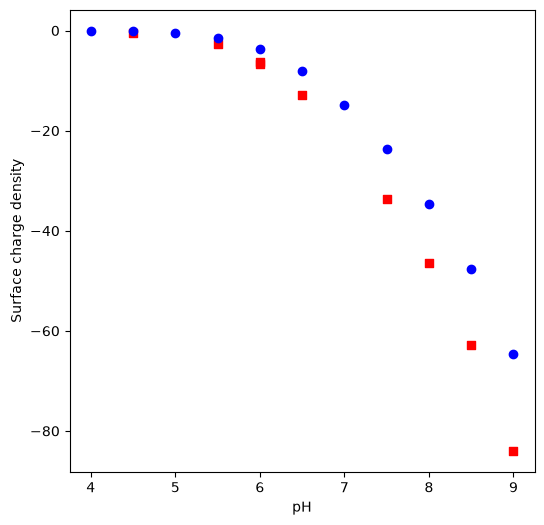

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

"""
Process simulation results stored in multiple folders, compute the average
values of the observables, export the consolidated data as a Markdown table,
and generate a scatter plot of surface charge density versus pH.

Inputs:
    base_dir: Directory containing the simulation subfolders.
    output_dir: Directory where the processed data and figures are saved.

Output:
    A Markdown file ("simulation_data.md") containing the consolidated
    simulation data and a scatter plot of surface charge density versus pH.
"""

# Define the input and output directories relative to the current working directory
base_dir = Path.cwd() / "simulation_data_files"
output_dir = Path.cwd() / "simulation_data_for_publication"
output_dir.mkdir(parents=True, exist_ok=True)

# Create a list to store the processed records
all_records = []

# Iterate through the simulation subfolders
for subfolder in base_dir.iterdir():
    if subfolder.is_dir():

        # Store the current folder name
        folder_name = subfolder.name

        # Build the path to the corresponding CSV file
        csv_file = subfolder / f"{folder_name}_obs.csv"

        if csv_file.exists():

            # Load the CSV file containing the simulation observables
            df_obs = pd.read_csv(csv_file)

            # Compute the mean value of each observable
            means = df_obs.astype(float).mean().to_dict()

            # Remove the time column from the averages
            means.pop('time')

            parts = folder_name.split('_')

            # Extract the numerical simulation parameters from the folder name
            sgD_val, rnp_val, ph_val = [
                float(x) for x in re.findall(r"[\d.]+", folder_name)
            ]

            # Create a record containing the simulation parameters
            # and the averaged observables
            record = {
                'sgD': sgD_val,
                'Rnp': rnp_val,
                'pH': ph_val,
                **means
            }

            # Store the record
            all_records.append(record)

# Build the consolidated DataFrame
master_df = pd.DataFrame(all_records)

# Export the DataFrame as a Markdown file
markdown_file = output_dir / 'simulation_data.md'
master_df.to_markdown(markdown_file, index=False)

# Filter and sort the data for plotting
case_1 = master_df[
    (master_df['sgD'] == 2.0) &
    (master_df['Rnp'] == 7.2)
].sort_values('pH')

case_2 = master_df[
    (master_df['sgD'] == 1.0) &
    (master_df['Rnp'] == 10.1)
].sort_values('pH')

# Create the figure
plt.figure(figsize=(6, 6))

# Case 1 (sgD = 2.0, Rnp = 7.2): red square markers
plt.scatter(
    case_1['pH'],
    case_1['surf_ch_dens'],
    color='red',
    marker='s'
)

# Case 2 (sgD = 1.0, Rnp = 10.1): blue circular markers
plt.scatter(
    case_2['pH'],
    case_2['surf_ch_dens'],
    color='blue',
    marker='o'
)

# Set the axis labels
plt.xlabel('pH')
plt.ylabel('Surface charge density')

# Display the figure (no grid, legend, or title)
plt.show()